# Lista de Exercícios 03
## Splines Cúbicos

**Programa:** PPGMC / UESC  
**Base:** Burden & Faires — Capítulo 3

---

## Objetivos

- Implementar o algoritmo de spline cúbico natural
- Analisar propriedades de suavidade
- Comparar com interpolação global
- Discutir estabilidade numérica

---

## Pseudocódigo — Spline Cúbico Natural

(Adaptado de Burden & Faires)

Para construir o interpolador spline cúbico $S$ para a função $f$, definida nos números $x_0 < x_1 < \dots < x_n$ , e satisfazendo $S''(x_0) = S''(x_n) = 0$ (spline cúbico natural):

INPUT: $n;\, x_0, x_1, \dots, x_n; \, a_0 = f(x_0), a_1 = f(x_1), \dots, a_n = f(x(n)$

OUTPUT: $a_j, b_j, c_j, d_j$ para $j=0,1,\dots,n-1$ 

1. Para $i=0,1,\dots,n-1$, fazer $h_i = x_{i+1} - x_i$

2. Para $i=1,2,\dots,n-1$, fazer

$$ \alpha_i = \frac{3}{h_i}(a_{i+1}-a_i) - \frac{3}{h_{i-1}}(a_i-a_{i-1})$$

3. Inicialização: $l_0=1, \mu_0=0, z_0=0$

4. Para $i=1,2,\dots,n-1$, fazer

   $$ l_i=2(x_{i+1}-x_{i-1}) - h_{i-1}\mu_{i-1} $$
   $$ \mu _i=\frac{h_i}{l_i} $$
   $$ z_i=\frac{(\alpha_i-h_{i-1}z_{i-1})}{l_i} $$

5. Condições finais: $l_n=1, z_n=0, c_n=0$

6. Para $j=n-1, n-2, \dots, 0$ fazer:
   
   $$ c_j=z_j-\mu_j*c_{j+1} $$
   $$ b_j=\frac{(a_{j+1}-a_j)}{h_j} - \frac{h_j(c_{j+1}+2c_j)}{3} $$
   $$ d_j=\frac{(c_{j+1}-c_j)}{(3h_j)} $$

7. OUTPUT: $a_j, b_j, c_j, d_j$ para $j=0,1,\dots,n-1$ 

---

## Observação

Você pode utilizar implementações como `scipy.interpolate.CubicSpline`
apenas para validar resultados, mas NÃO para resolver os exercícios.

## Exercício 1.

Implemente o spline cúbico natural para um conjunto simples de 5 pontos gerados por você mesmo.

Mostre:
- coeficientes
- gráfico do spline

In [1]:
import numpy as np

# Inicialização dos pontos
x = [1,2,3,4,7]
y = [1,4,3,2,10]

# Implementação do método de spline cúbico
def spline(x, y):
    n = len(x)
    h = np.zeros(n - 1)
    for i in range(n - 1):
        h[i] = x[i+1] - x[i]
    
    alpha = np.zeros(n - 1)
    for i in range(1, n - 1):
        alpha[i] = (3/h[i])*(y[i+1] - y[i]) - (3/h[i-1])*(y[i] - y[i-1])
    
    l = np.ones(n)
    mu = np.zeros(n)
    z = np.zeros(n)
    
    for i in range(1, n - 1):
        l[i] = 2*(x[i+1] - x[i-1]) - h[i-1]*mu[i-1]
        mu[i] = h[i]/l[i]
        z[i] = (alpha[i] - h[i-1]*z[i-1])/l[i]
    
    b = np.zeros(n)
    c = np.zeros(n)
    d = np.zeros(n)
    
    for j in range(n-2, -1, -1):
        c[j] = z[j] - mu[j] * c[j+1]
        b[j] = (y[j+1] - y[j])/h[j] - (h[j]*(c[j+1] + 2*c[j]))/3
        d[j] = (c[j+1] - c[j])/(3*h[j])
        
    return b[:-1], c[:-1], d[:-1]

# Cálculo dos coeficientes do spline cúbico
b,c,d = spline(x,y)

print("Coeficientes b:", b)
print("Coeficientes c:", c)
print("Coeficientes d:", d)


Coeficientes b: [ 4.03735632  0.92528736 -1.73850575  0.02873563]
Coeficientes c: [ 0.         -3.11206897  0.44827586  1.31896552]
Coeficientes d: [-1.03735632  1.18678161  0.29022989 -0.14655172]


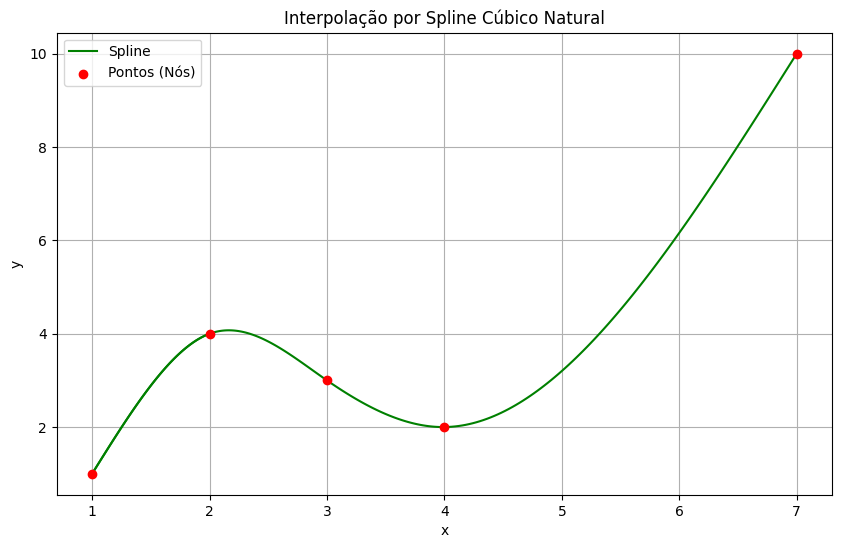

In [2]:
import matplotlib.pyplot as plt

# Plotagem
plt.figure(figsize=(10, 6))

for j in range(len(x) - 1):
    
    x_vals = np.linspace(x[j], x[j+1], 100)
    dx = x_vals - x[j]
    y_vals = y[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    if j == 0:    
        plt.plot(x_vals, y_vals, color='green', label='Spline', zorder=3)
    plt.plot(x_vals, y_vals, color='green')

plt.scatter(x, y, color='red', zorder=5, label='Pontos (Nós)')
plt.title('Interpolação por Spline Cúbico Natural')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Exercício 2.

Implemente o spline cúbico natural para um conjunto simples de pontos gerados utilizando a função $\sin(x)$ no intervalo entre $0 \leq x \leq \pi$. 

Mostre:
- coeficientes
- gráfico do spline

Coeficientes b: [ 0.99991631  0.93961398  0.76598034  0.49995816  0.17363365 -0.17363365
 -0.49995816 -0.76598034 -0.93961398]
Coeficientes c: [ 0.         -0.17275346 -0.3246703  -0.43742711 -0.49742375 -0.49742375
 -0.43742711 -0.3246703  -0.17275346]
Coeficientes d: [-1.64967399e-01 -1.45069896e-01 -1.07674823e-01 -5.72925766e-02
 -5.30092447e-16  5.72925766e-02  1.07674823e-01  1.45069896e-01
  1.64967399e-01]


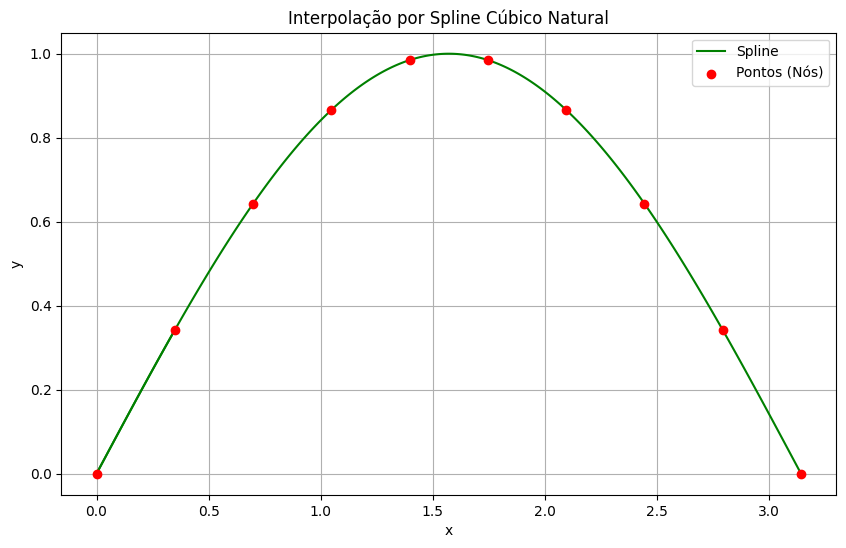

In [3]:
# Inicialização dos pontos
x = np.linspace(0, np.pi, 10)
y = np.sin(x)

# Cálculo dos coeficientes do spline cúbico
b,c,d = spline(x,y)

print("Coeficientes b:", b)
print("Coeficientes c:", c)
print("Coeficientes d:", d)

# Plotagem
plt.figure(figsize=(10, 6))

for j in range(len(x) - 1):
    
    x_vals = np.linspace(x[j], x[j+1], 100)
    dx = x_vals - x[j]
    y_vals = y[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    
    if j == 0:    
        plt.plot(x_vals, y_vals, color='green', label='Spline', zorder=3)
    plt.plot(x_vals, y_vals, color='green')

plt.scatter(x, y, color='red', zorder=5, label='Pontos (Nós)')
plt.title('Interpolação por Spline Cúbico Natural')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Exercício 3.

Implemente o spline cúbico natural para um conjunto simples de pontos gerados utilizando a função $e^x$ para $-1 \leq x \leq 1$.

Mostre:
- coeficientes
- gráfico do spline

Coeficientes b: [0.39137948 0.45311721 0.57545041 0.71600523 0.89518829 1.11657637
 1.39894321 1.73041485 2.22313373]
Coeficientes c: [0.         0.27781978 0.27267962 0.35981706 0.44650671 0.54973966
 0.72091113 0.77071125 1.4465237 ]
Coeficientes d: [ 0.41672967 -0.00771025  0.13070617  0.13003447  0.15484942  0.25675722
  0.07470018  1.01371867 -2.16978555]


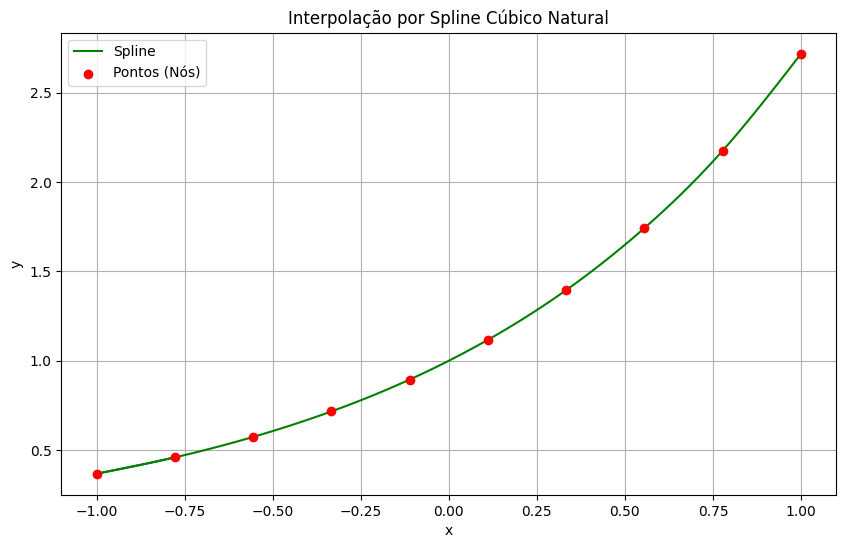

In [4]:
# Inicialização dos pontos
x = np.linspace(-1, 1, 10)
y = np.exp(x)

# Cálculo dos coeficientes do spline cúbico
b,c,d = spline(x,y)

print("Coeficientes b:", b)
print("Coeficientes c:", c)
print("Coeficientes d:", d)

# Plotagem
plt.figure(figsize=(10, 6))

for j in range(len(x) - 1):
    
    x_vals = np.linspace(x[j], x[j+1], 100)
    dx = x_vals - x[j]
    y_vals = y[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    
    if j == 0:    
        plt.plot(x_vals, y_vals, color='green', label='Spline', zorder=3)
    plt.plot(x_vals, y_vals, color='green')

plt.scatter(x, y, color='red', zorder=5, label='Pontos (Nós)')
plt.title('Interpolação por Spline Cúbico Natural')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


## Exercício 4.

Implemente o spline cúbico natural para um conjunto simples de pontos.

Mostre:
- coeficientes
- gráfico do spline

Coeficientes b: [  0.77502504   2.44994991   0.54179189  -3.65065115  12.05007834
 -11.87005779  -3.56984718  17.14944651  -4.25698472]
Coeficientes c: [  0.           0.55830829  -2.46646631   0.37024479   2.76990111
 -26.69003724  34.99024785 -14.27095415   3.56773854]
Coeficientes d: [  0.06203425  -1.0082582    0.47278518   0.15997709  -9.81997945
  20.56009503 -16.42040067   2.97311545  -0.59462309]


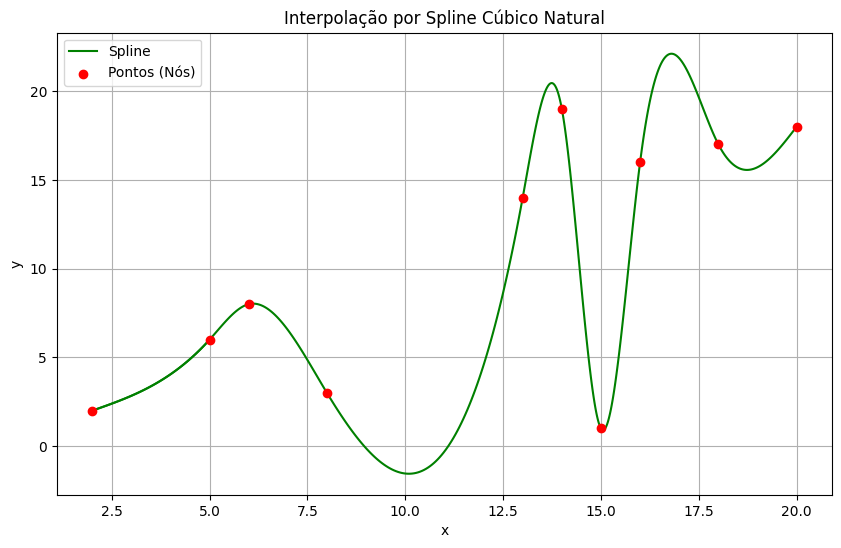

In [5]:
# Inicialização dos pontos

x = [2, 5, 6, 8, 13, 14, 15, 16, 18, 20]
y = [2, 6, 8, 3, 14, 19, 1, 16, 17, 18]

# Cálculo dos coeficientes do spline cúbico
b,c,d = spline(x,y)

print("Coeficientes b:", b)
print("Coeficientes c:", c)
print("Coeficientes d:", d)

# Plotagem
plt.figure(figsize=(10, 6))

for j in range(len(x) - 1):
    
    x_vals = np.linspace(x[j], x[j+1], 100)
    dx = x_vals - x[j]
    y_vals = y[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    if j == 0:    
        plt.plot(x_vals, y_vals, color='green', label='Spline', zorder=3)
    plt.plot(x_vals, y_vals, color='green')

plt.scatter(x, y, color='red', zorder=5, label='Pontos (Nós)')
plt.title('Interpolação por Spline Cúbico Natural')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


## Exercício 5.

Compare spline com interpolação polinomial global.
Use função de Runge.

/var/folders/qw/v1v41zkx3w53m8bcz3ng_tqw0000gn/T/ipykernel_7941/632377250.py:47: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x_plot, y_true, 'k--', alpha=0.5, color='black', label='Função Original', zorder=3)


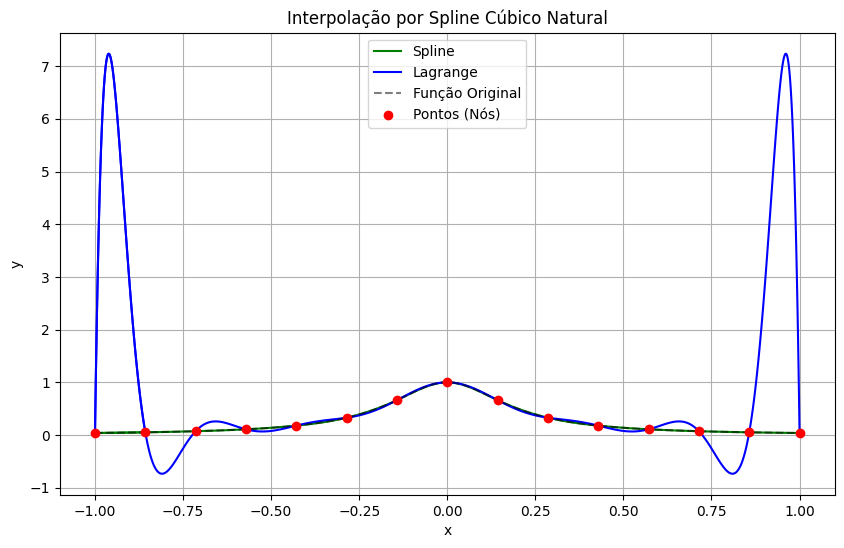

In [6]:
# Função de Runge

def runge(x):
    return 1 / (1 + 25*x**2)

# Função de Lagrange
def lagrange(x_alvo,x,y):
    grau = len(x)
    soma = 0.0
    for i in range(grau):
        mult = y[i]
        for j in range(grau):
            if i != j:
                mult *= ((x_alvo - x[j]) / (x[i] - x[j]))
        soma += mult 
    return soma  

# Inicialização dos pontos
x = np.linspace(-1, 1, 15)
y = runge(x)

# Cálculo dos coeficientes do spline cúbico
b,c,d = spline(x,y)

# Plotagem
plt.figure(figsize=(10, 6))

for j in range(len(x) - 1):
    
    x_vals = np.linspace(x[j], x[j+1], 100)
    dx = x_vals - x[j]
    y_spline = y[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    y_lagrange = lagrange(x_vals, x, y)

    if j == 0:    
        plt.plot(x_vals, y_spline, color='green', label='Spline', zorder=3)
        plt.plot(x_vals , y_lagrange, color='blue', label='Lagrange', zorder=3)

    
    plt.plot(x_vals, y_spline, color='green', zorder=3)
    plt.plot(x_vals , y_lagrange, color='blue', zorder=3)

x_plot = np.linspace(-1, 1, 500)
y_true = runge(x_plot)


plt.plot(x_plot, y_true, 'k--', alpha=0.5, color='black', label='Função Original', zorder=3)
plt.scatter(x, y, color='red', zorder=10, label='Pontos (Nós)')
plt.title('Interpolação por Spline Cúbico Natural')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Exercício 6.

Adicione pequenas perturbações nos dados e analise estabilidade.

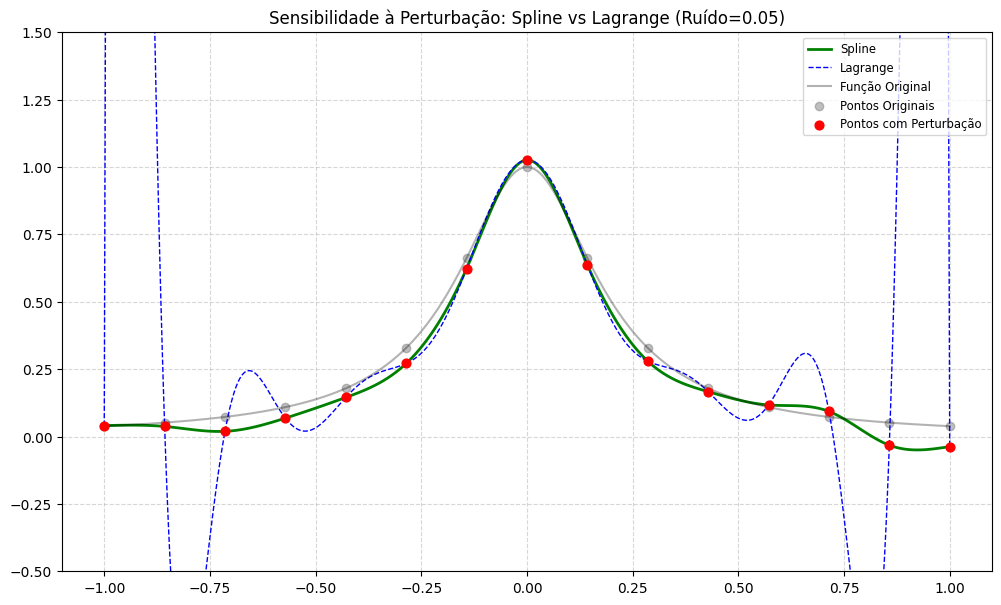

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Inicialização dos pontos
x = np.linspace(-1, 1, 15)
y_puro = runge(x)

# Adição de ruído aos valores de y
ruido = 0.05
y_ruido = y_puro + np.random.normal(0, ruido, len(y_puro))

# Cálculo dos coeficientes
b, c, d = spline(x, y_ruido)

# Plotagem
plt.figure(figsize=(12, 7))

x_plot = np.linspace(-1, 1, 500)
y_true = runge(x_plot)

# Plotar as curvas de interpolação
for j in range(len(x) - 1):
    x_intervalo = np.linspace(x[j], x[j+1], 50)
    dx = x_intervalo - x[j]
    
    y_spline = y_ruido[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    y_lagrange = lagrange(x_intervalo, x, y_ruido)

    label_s = 'Spline' if j == 0 else ""
    label_l = 'Lagrange' if j == 0 else ""
    
    plt.plot(x_intervalo, y_spline, color='green', lw=2, label=label_s)
    plt.plot(x_intervalo, y_lagrange, color='blue', lw=1, linestyle='--', label=label_l)

plt.plot(x_plot, y_true, 'k-', alpha=0.3, label='Função Original')
plt.scatter(x, y_puro, color='gray', alpha=0.5, label='Pontos Originais')
plt.scatter(x, y_ruido, color='red', s=40, zorder=10, label='Pontos com Perturbação')

plt.title(f'Sensibilidade à Perturbação: Spline vs Lagrange (Ruído={ruido})')
plt.ylim(-0.5, 1.5)
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

## Exercício 7.

Compare spline com interpolação linear por partes. Utilize o conjunto de pontos do Exercício 2. 

Coeficientes b: [ 0.99991631  0.93961398  0.76598034  0.49995816  0.17363365 -0.17363365
 -0.49995816 -0.76598034 -0.93961398]
Coeficientes c: [ 0.         -0.17275346 -0.3246703  -0.43742711 -0.49742375 -0.49742375
 -0.43742711 -0.3246703  -0.17275346]
Coeficientes d: [-1.64967399e-01 -1.45069896e-01 -1.07674823e-01 -5.72925766e-02
 -5.30092447e-16  5.72925766e-02  1.07674823e-01  1.45069896e-01
  1.64967399e-01]


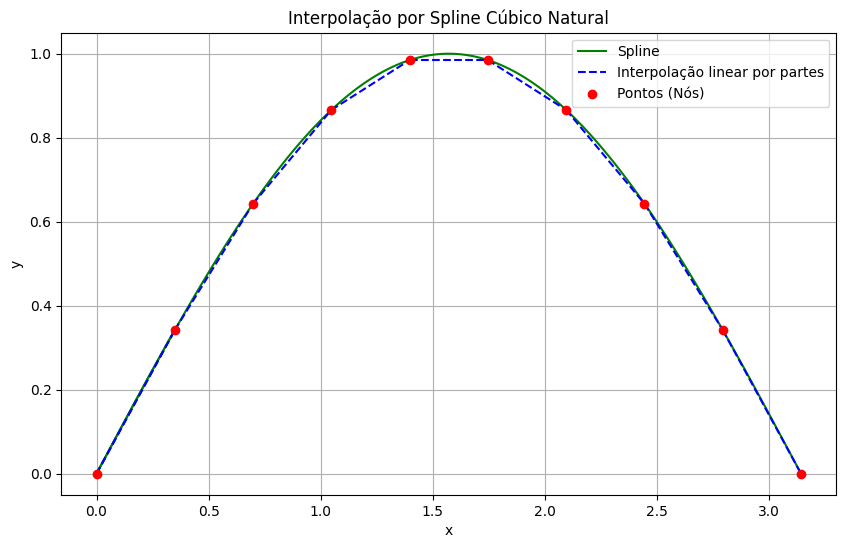

In [8]:
# Inicialização dos pontos
x = np.linspace(0, np.pi, 10)
y = np.sin(x)

# Cálculo dos coeficientes do spline cúbico
b,c,d = spline(x,y)

print("Coeficientes b:", b)
print("Coeficientes c:", c)
print("Coeficientes d:", d)

# Plotagem
plt.figure(figsize=(10, 6))

for j in range(len(x) - 1):

    x_seg = x[j:j+2]
    y_seg = y[j:j+2]
    
    x_vals = np.linspace(x[j], x[j+1], 100)
    dx = x_vals - x[j]
    y_vals = y[j] + b[j]*dx + c[j]*(dx**2) + d[j]*(dx**3)
    y_linear = [lagrange(val, x_seg, y_seg) for val in x_vals]
    
    if j == 0:    
        plt.plot(x_vals, y_vals, color='green', label='Spline', zorder=3)
        plt.plot(x_vals, y_linear, color='blue', label='Interpolação linear por partes', linestyle='--', zorder=3)
    plt.plot(x_vals, y_vals, color='green')
    plt.plot(x_vals, y_linear, color='blue',linestyle='--')

plt.scatter(x, y, color='red', zorder=5, label='Pontos (Nós)')
plt.title('Interpolação por Spline Cúbico Natural')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Exercício 8.

Analíse a implementação do algoritmo do spline cúbico natural feita com base no slgoritmo discutido em sala de aula.

Discuta:
- custo computacional: Compare a complexidade de tempo com a interpolação global utilizando 4, 8 e 16 pontos de interpolção 
- estabilidade: Compare o resultado de introduzir pequenas perturbações nos seus dados em relação à interpolação global. 

Pontos     | Média Lagrange (ms)  | Média Spline (ms)   
-------------------------------------------------------
4          | 0.23554              | 0.00978             
8          | 0.94641              | 0.01678             
16         | 3.87872              | 0.03253             


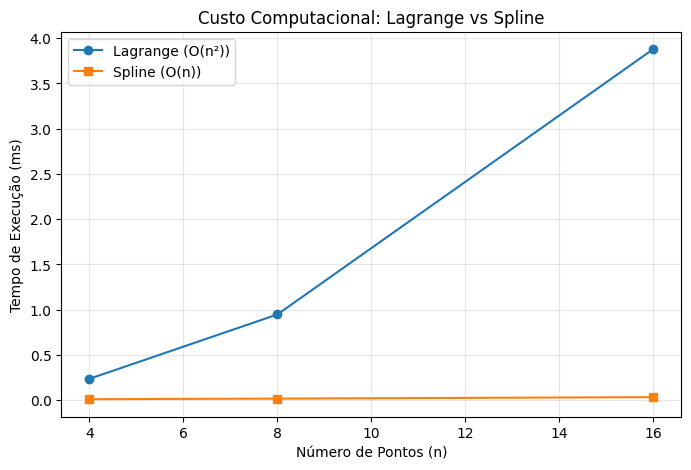

In [9]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Função para comparar o custo computacional de Lagrange e Spline
def comparar_custo():
    tamanhos = [4, 8, 16]
    repeticoes = 1000  
    
    resultados_lagrange = []
    resultados_spline = []

    print(f"{'Pontos':<10} | {'Média Lagrange (ms)':<20} | {'Média Spline (ms)':<20}")
    print("-" * 55)

    for n in tamanhos:
        x = np.linspace(0, np.pi, n)
        y = np.sin(x)
        
        start = time.perf_counter()
        for _ in range(repeticoes):
            x_plot = np.linspace(0, np.pi, 100)
            _ = [lagrange(val, x, y) for val in x_plot]
        end = time.perf_counter()
        tempo_lagrange = (end - start) / repeticoes * 1000 

        start = time.perf_counter()
        for _ in range(repeticoes):
            b, c, d = spline(x, y)
            x_plot = np.linspace(0, np.pi, 100)
        end = time.perf_counter()
        tempo_spline = (end - start) / repeticoes * 1000 

        resultados_lagrange.append(tempo_lagrange)
        resultados_spline.append(tempo_spline)
        
        print(f"{n:<10} | {tempo_lagrange:<20.5f} | {tempo_spline:<20.5f}")

    
    plt.figure(figsize=(8, 5))
    plt.plot(tamanhos, resultados_lagrange, 'o-', label='Lagrange (O(n²))')
    plt.plot(tamanhos, resultados_spline, 's-', label='Spline (O(n))')
    plt.xlabel('Número de Pontos (n)')
    plt.ylabel('Tempo de Execução (ms)')
    plt.title('Custo Computacional: Lagrange vs Spline')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

comparar_custo()

Como visto no código acima, o spline cúbico natural conseguiu uma tempo menor que a interpolação global com usando a interpolação de Lagrange nos testes realizados. Também é possível observar no exercício número 6 que o spline é um algoritmo mais estável. Assim podemos confirmar que seguindo esses dois critérios, o spline cúbico natural se mostrou superior a interpolação global.